In [1]:
import copy
import os
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyref.fitting as fit
from matplotlib.figure import Figure
from refnx.analysis import Transform

fit_data = Path.cwd().parent.parent / "data" / "processed" / "fitting"
models_dir = Path.cwd().parent.parent / "models" / "fitting_results"

CPU_COUNT = os.cpu_count() | 8
CPU_COUNT

40

(<Axes: ylabel='$R$'>, <Axes: xlabel='$q (\\AA^{-1})$'>)

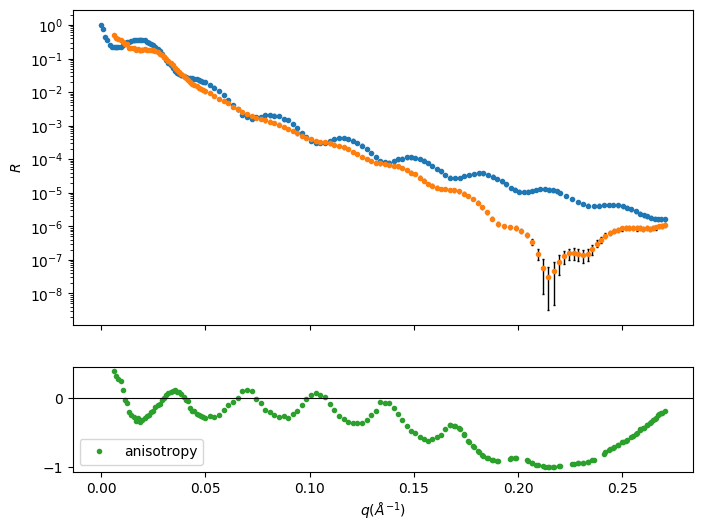

In [2]:
from utils import read_fit, read_ooc, read_xrr


loaded_data = read_xrr("reflectivity_data", material="znpc")
loaded_data["283.7"].plot(label="283.7 eV data")

In [3]:
from utils import models_root
fitting_results = read_fit(models_root/"xrr"/"dft"/"dft_en_offset_best.pkl")

In [4]:
def select(global_objective, slab, energy):
    for o in global_objective.objectives:
        if o.model.energy == energy:
            for s in o.model.structure.components:
                if s.name.startswith(slab):
                    return s
            raise ValueError(f"No slab {slab} found in energy {energy}")
    raise ValueError(f"No energy {energy} found in global objective")

select(fitting_results, "Surface", 283.7).thick.setp(bounds=(0, 35))
select(fitting_results, "Surface", 283.7).rough.setp(bounds=(0, 25))
select(fitting_results, "Surface", 283.7).sld.rotation.setp(bounds=(0, np.pi/2))
select(fitting_results, "Surface", 283.7).sld.density.setp(bounds=(.5, 2))

select(fitting_results, "ZnPc", 283.7).thick.setp(bounds=(160, 200))
select(fitting_results, "ZnPc", 283.7).rough.setp(bounds=(0, 25))
select(fitting_results, "ZnPc", 283.7).sld.rotation.setp(
    bounds=(np.deg2rad(55), np.deg2rad(90)))

select(fitting_results, "Contamination", 283.7).thick.setp(bounds=(0, 35))
select(fitting_results, "Contamination", 283.7).rough.setp(bounds=(0, 25))
select(fitting_results, "Contamination", 283.7).sld.rotation.setp(bounds=(0, np.pi/2))
select(fitting_results, "Contamination", 283.7).sld.density.setp(bounds=(.5, 2))

select(fitting_results, "Oxide", 283.7).thick.setp(bounds=(0, 20))
select(fitting_results, "Oxide", 283.7).rough.setp(bounds=(0, 25))

In [46]:
from utils.helpers.fitting_helper import CurveFitter, ObjectiveType, aic, bic, reduced_chi2
from uncertainties import ufloat
from refnx.analysis import Parameter, Parameters

def to_dict(param):
    return{
        "value": ufloat(
            param.value,
            param.stderr if param.stderr is not None else 0
        ),
        "ub": param.bounds.ub,
        "lb": param.bounds.lb,
        "vary": param.vary,
        "constrained": True if param.constraint is not None else False,
    }

def from_model(model: fit.ReflectModel, overload_constraint_energy: float | None = None):
    # Filter warnings
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning)
    dfs = []
    for i, p in enumerate(model.parameters):
        if isinstance(p, Parameters):
            if i ==0:
                # The first parameter group is the energy specific instrument parameters
                group = p.name
                for param in p:
                    row = {
                        "energy": model.energy,
                        "group": group,
                        "kind": param.name,
                        **to_dict(param),
                        "constraint_energy": (
                            overload_constraint_energy if param.constraint is not None else None
                        )
                    }
                    dfs.append(pd.DataFrame([row]))
            else:
                for slab_group in p:
                    group = slab_group.name.split("_")[0].lower()
                    for i, param in enumerate(slab_group):
                        if i == 0:
                            # Structure parameters
                            for struct_param in param:
                                name = struct_param.name.split("_")[-1]
                                row = {
                                    "energy": model.energy,
                                    "group": group,
                                    "kind": name,
                                    **to_dict(struct_param),
                                    "constraint_energy": (
                                        overload_constraint_energy if struct_param.constraint is not None else None
                                    )
                                }
                                dfs.append(pd.DataFrame([row]))
                        else:
                            # SLD parameters are not in a group
                            name = param.name.split("_")[-1]
                            row = {
                                "energy": model.energy,
                                "group": group,
                                "kind": name,
                                **to_dict(param),
                                "constraint_energy": (
                                    overload_constraint_energy if param.constraint is not None else None
                                )
                            }
                            dfs.append(pd.DataFrame([row]))
    df = pd.concat(dfs, ignore_index=True)
    return df

def from_global_objective(global_objective: fit.GlobalObjective):
    dfs = []
    for o in global_objective.objectives:
        dfs.append(from_model(o.model))
    return pd.concat(dfs, ignore_index=True).sort_values(by=["group", "kind", "energy"])

In [83]:
# Grab the places where the parameter constraint is not None
df = from_global_objective(fitting_results)
df.to_pickle(models_root/"xrr"/"dft"/"params_v1.pkl")

for energy, group in df.where(
    ~(df["constrained"]) & (df["vary"]) & (df["group"] != "instrument parameters")
).groupby(["energy", "group"]):
    display(group)

,energy,group,kind,value,ub,lb,vary,constrained,constraint_energy
584,283.7,contamination,density,1.76+/-0.33,2.000000,0.5,True,False,None
585,283.7,contamination,rotation,0.98662+/-0.00015,1.570796,0.0,True,False,None
583,283.7,contamination,rough,3.2886+/-0.0005,25.000000,0.0,True,False,None
582,283.7,contamination,thick,19.1945+/-0.0031,35.000000,0.0,True,False,None


,energy,group,kind,value,ub,lb,vary,constrained,constraint_energy
589,283.7,oxide,rho,1.87517+/-0.00030,2.47,1.0,True,False,None
588,283.7,oxide,rough,9.9959+/-0.0015,25.00,0.0,True,False,None
587,283.7,oxide,thick,1.52162+/-0.00024,20.00,0.0,True,False,None


,energy,group,kind,value,ub,lb,vary,constrained,constraint_energy
593,283.7,substrate,rho,2.6303+/-0.0004,3.0,2.0,True,False,None


,energy,group,kind,value,ub,lb,vary,constrained,constraint_energy
574,283.7,surface,density,1.77+/-0.35,2.000000,0.5,True,False,None
575,283.7,surface,rotation,0.82944+/-0.00013,1.570796,0.0,True,False,None
573,283.7,surface,rough,6.7866+/-0.0011,25.000000,0.0,True,False,None
572,283.7,surface,thick,2.9749+/-0.0004,35.000000,0.0,True,False,None


,energy,group,kind,value,ub,lb,vary,constrained,constraint_energy
579,283.7,znpc,density,1.67016+/-0.00027,1.800000,1.200000,True,False,None
580,283.7,znpc,rotation,1.20942+/-0.00020,1.570796,0.959931,True,False,None
578,283.7,znpc,rough,15.0518+/-0.0024,25.000000,0.000000,True,False,None
577,283.7,znpc,thick,180.957+/-0.029,200.000000,160.000000,True,False,None


ValueError: could not convert string to float: '1.76+/-0.33'

In [5]:
def x0(fitter):
    o = fitter.objective
    p0 = o.varying_parameters()
    return np.array([o.value for o in p0])

def bounds(p, override_chain=False):
    if np.shape(p.chain) == () or override_chain:
        return (
            (p.value - p.stderr) * 0.8,
            (p.value + p.stderr) * 1.2
        )
    else:
        return (p.chain[-1].min() * 0.8, p.chain[-1].max() * 1.2)


def update_bounds(fitter, override_chain=False):
    p0 = fitter.objective.varying_parameters()
    for p in p0:

        if p.name.split("_")[-1] in ["rotation"]:
            continue
        # Update the bounds
        p.setp(bounds=bounds(p, override_chain))

In [9]:
# Let's construct an internal optimization for e in {250.0, 283.7, 284.2, 285.1, 287.0, 289.0}
internal_energies: list[float] = [250.0, 283.7, 284.2, 285.1, 287.0, 289.0]
internal_objectives = [o for o in fitting_results.objectives if o.model.energy in internal_energies]

for o in internal_objectives:
    fitter = fit.CurveFitter(o)
    fitter.fit("differential_evolution",
        workers=CPU_COUNT//2, updating="deferred")
    update_bounds(o, override_chain=True)
    fitter.fit("L-BFGS-B")
    update_bounds(o, override_chain=True)
    fitter.fit("differential_evolution",
        workers=CPU_COUNT//2, updating="deferred")


0it [00:35, ?it/s]


RuntimeError: The map-like callable must be of the form f(func, iterable), returning a sequence of numbers the same length as 'iterable'

In [ ]:
# Fit the global objective
fitter = fit.CurveFitter(global_objective)
fitter.fit("differential_evolution",
    workers=CPU_COUNT//2, updating="deferred", x0=x0(fitter))

0it [00:00, ?it/s]Process ForkPoolWorker-7:
Process ForkPoolWorker-9:
Process ForkPoolWorker-16:
Process ForkPoolWorker-12:
Process ForkPoolWorker-6:
Process ForkPoolWorker-18:
Process ForkPoolWorker-19:
Process ForkPoolWorker-15:
Process ForkPoolWorker-17:
Process ForkPoolWorker-14:
Process ForkPoolWorker-13:
Process ForkPoolWorker-8:
Process ForkPoolWorker-11:
Process ForkPoolWorker-1:
Process ForkPoolWorker-20:
Process ForkPoolWorker-2:
Process ForkPoolWorker-10:
Process ForkPoolWorker-3:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (mo

In [ ]:
fitter.fit("differential_evolution", workers=CPU_COUNT//2, updating="deferred", x0=x0(fitter))

In [ ]:
update_bounds(fitter, override_chain=True)
fitter.fit("L-BFGS-B")
update_bounds(fitter, override_chain=True)
fitter.fit("differential_evolution", workers=CPU_COUNT//2, updating="deferred", x0=x0(fitter))
update_bounds(fitter, override_chain=True)

In [ ]:
fitter.initialise("jitter", random_state=12345)
fitter.sample(200)
update_bounds(fitter)
fitter.reset()
fitter.sample(1000)
print(global_objective.varying_parameters())

In [ ]:
plt.plot(-fitter.logpost, alpha=0.5)
plt.show()

In [ ]:
global_objective.plot()
plt.show()
global_objective.corner()
plt.show()

In [ ]:
with open("fitting_results_fixed_4.pkl", "wb") as f:
    pickle.dump(fitting_results, f)